# Flight Delay Prediction: Baseline Model

Working notebook for the [Zindi Flight Delay Prediction Challenge](https://zindi.africa/competitions/flight-delay-prediction-challenge) (Tunisair). This notebook builds Milestone 1: the **baseline model**, following the plan in `Flight_Delay_Baseline_and_Strategy_Report.pdf`.

## Define the Business Goal

- **Stakeholder:** Tunisair operations / the Zindi organisers evaluating submissions.
- **Prediction:** the delay of a given Tunisair flight, **in minutes** (can be negative for an early departure/arrival).
- **Problem type:** regression -- the target is a continuous number, not a delayed/not-delayed label.
- **Evaluation metric: Root Mean Squared Error (RMSE).** RMSE squares each error before averaging, so a few very large misses hurt the score far more than many small ones. This favours models that avoid big outlier misses over models that are only accurate on average, and it is also the metric the Zindi leaderboard scores submissions on.
- **Baseline model:** the simplest rule that makes a prediction. Three are built below -- a **naive mean/median predictor** (the absolute floor), a **route group-mean predictor**, and a **Ridge regression** on basic engineered features (the first "real" ML baseline). Every later, more complex model (Random Forest, XGBoost, ...) must beat these to justify its added complexity.

## Get the Data

We import the cleaned data from `data_cleaning.ipynb` (`data/cleaned_data.csv`), which keeps the flight date (`datop`) alongside the other cleaned columns so we can build a chronological train/test split below.

In [24]:
import pandas as pd

data = pd.read_csv("data/cleaned_data.csv")
data["datop"] = pd.to_datetime(data["datop"])

data.head()

/var/folders/60/p84z97d51rz4wdn4800x9x1r0000gn/T/ipykernel_26537/234456840.py:3: DtypeWarning: Columns (0: fltid_number) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv("data/cleaned_data.csv")


,id,datop,depstn,arrstn,std,sta,target,scheduled_week_day_of_departure,scheduled_month_of_departure,scheduled_year_of_departure,...,scheduled_minutes_of_departure,scheduled_week_day_of_arrival,scheduled_month_of_arrival,scheduled_year_of_arrival,scheduled_hour_of_arrival,scheduled_minutes_of_arrival,fltid_airline,fltid_number,ac_type,ac_tail
0,0,2016-01-03,CMN,TUN,2016-01-03 10:30:00,2016-01-03 12:55:00,260.0,Sunday,January,2016,...,30,Sunday,January,2016,12,55,TU,0712,32A,IMN
1,1,2016-01-13,MXP,TUN,2016-01-13 15:05:00,2016-01-13 16:55:00,20.0,Wednesday,January,2016,...,5,Wednesday,January,2016,16,55,TU,0757,31B,IMO
2,2,2016-01-16,TUN,IST,2016-01-16 04:10:00,2016-01-16 06:45:00,0.0,Saturday,January,2016,...,10,Saturday,January,2016,6,45,TU,0214,32A,IMN
3,3,2016-01-17,DJE,NTE,2016-01-17 14:10:00,2016-01-17 17:00:00,0.0,Sunday,January,2016,...,10,Sunday,January,2016,17,0,TU,0480,736,IOK
4,4,2016-01-17,TUN,ALG,2016-01-17 14:30:00,2016-01-17 15:50:00,22.0,Sunday,January,2016,...,30,Sunday,January,2016,15,50,TU,0338,320,IMU


## Feature engineering

Safe to do before split because of the time based split logic

In [25]:
# route col creation
data['route'] = data['depstn'] + '_' + data['arrstn']

print(data['depstn'].nunique(), data['arrstn'].nunique())
print(data['route'].nunique())  # see how many unique routes exist
data['route'].value_counts().head(10)  # most common routes


132 128
741


route
ORY_TUN    4579
TUN_ORY    4564
TUN_TUN    4320
DJE_TUN    3645
TUN_DJE    3521
TUN_MRS    2233
MRS_TUN    2217
ALG_TUN    1567
TUN_ALG    1564
TUN_MXP    1469
Name: count, dtype: int64

In [26]:
# delay propagation cols creation (safe to do before split cause we have time-based split which avoid leakage)
import numpy as np

data = data.sort_values("datop")
data['day'] = data['datop'].dt.date

def expanding_shifted_mean(df, group_cols):
    return (
        df.groupby(group_cols)['target']
          .transform(lambda x: x.expanding().mean().shift(1))
    )

# This is still using apply/transform with a lambda, so let's go fully vectorized instead:

for group_cols, colname in [
    (['ac_tail', 'day'], 'delay_prop_aircraft'),
    (['route', 'day'], 'delay_prop_route'),
    (['depstn', 'day'], 'delay_prop_depstn'),
    (['fltid_airline', 'day'], 'delay_prop_airline'),
]:
    grouped = data.groupby(group_cols)['target']
    cumsum = grouped.cumsum() - data['target']  # sum of prior rows in the group
    cumcount = grouped.cumcount()  # count of prior rows in the group
    data[colname] = (cumsum / cumcount.replace(0, np.nan))

prop_cols = ['delay_prop_aircraft', 'delay_prop_route', 'delay_prop_depstn', 'delay_prop_airline']
data[prop_cols] = data[prop_cols].fillna(0)

In [27]:
data = data.sort_values("datop").reset_index(drop=True)

def expanding_avg(df, group_col, target_col='target'):
    grouped = df.groupby(group_col)[target_col]
    cumsum = grouped.cumsum() - df[target_col]   # sum of all PRIOR rows in the group
    cumcount = grouped.cumcount()                 # count of all PRIOR rows in the group
    return cumsum / cumcount.replace(0, np.nan)

data['average_delay_per_airline'] = expanding_avg(data, 'fltid_airline')
data['average_delay_per_route']   = expanding_avg(data, 'route')
data['average_delay_per_depstn']  = expanding_avg(data, 'depstn')
data['average_delay_per_arrstn']  = expanding_avg(data, 'arrstn')

avg_cols = ['average_delay_per_airline', 'average_delay_per_route',
            'average_delay_per_depstn', 'average_delay_per_arrstn']
data[avg_cols] = data[avg_cols].fillna(data['target'].mean())  # fallback for first occurrence of each group

In [28]:
# flight_duration col creation
data['flight_duration'] = (pd.to_datetime(data['sta']) - pd.to_datetime(data['std'])).dt.total_seconds() / 60
data = data.drop(columns=["sta", "std"])

In [29]:
# create crosses_year, is_weekend, is_night, is_holiday columns
import holidays

# --- crosses_year ---
data['crosses_year'] = (
    data['scheduled_year_of_departure'] != data['scheduled_year_of_arrival']
).astype(int)

# --- is_weekend ---
data['is_weekend'] = data['scheduled_week_day_of_departure'].isin(['Saturday', 'Sunday']).astype(int)

# --- is_night (example window: 22:00–05:59) ---
data['is_night'] = data['scheduled_hour_of_departure'].apply(
    lambda h: 1 if (h >= 22 or h < 6) else 0
)

# --- is_holiday ---
# Adjust country code(s) based on your actual departure airports (e.g. Tunisia for TU flights)
tn_holidays = holidays.Tunisia(years=range(data['scheduled_year_of_departure'].min(),
                                             data['scheduled_year_of_departure'].max() + 1))

data['is_holiday'] = data['datop'].dt.date.isin(tn_holidays).astype(int)
# print(len(tn_holidays))  # should be a small number (roughly 10-20 per year), not ~104 (every weekend)
# print(list(tn_holidays.items())[:10])  # peek at a few actual entries
data.head(10)

,id,datop,depstn,arrstn,target,scheduled_week_day_of_departure,scheduled_month_of_departure,scheduled_year_of_departure,scheduled_hour_of_departure,scheduled_minutes_of_departure,...,delay_prop_airline,average_delay_per_airline,average_delay_per_route,average_delay_per_depstn,average_delay_per_arrstn,flight_duration,crosses_year,is_weekend,is_night,is_holiday
0,4510,2016-01-01,TUN,TLS,14.0,Friday,January,2016,7,30,...,0.000000,48.733013,48.733013,48.733013,48.733013,115.0,0,0,0,1
1,15119,2016-01-01,MXP,TUN,0.0,Friday,January,2016,15,5,...,31.017544,14.000000,48.733013,48.733013,48.733013,115.0,0,0,0,1
2,15118,2016-01-01,BRU,TUN,101.0,Friday,January,2016,17,25,...,29.767857,7.000000,48.733013,48.733013,0.000000,160.0,0,0,0,1
3,15117,2016-01-01,VCE,TUN,0.0,Friday,January,2016,15,35,...,30.309091,38.333333,48.733013,48.733013,50.500000,105.0,0,0,0,1
4,15116,2016-01-01,TUN,ORY,17.0,Friday,January,2016,14,30,...,30.555556,28.750000,48.733013,14.000000,48.733013,150.0,0,0,0,1
5,15115,2016-01-01,TUN,CMN,16.0,Friday,January,2016,14,10,...,30.830189,26.400000,48.733013,15.500000,48.733013,165.0,0,0,0,1
6,6909,2016-01-01,MRS,TUN,20.0,Friday,January,2016,10,20,...,31.038462,24.666667,48.733013,48.733013,33.666667,95.0,0,0,0,1
7,33179,2016-01-01,TUN,TUN,0.0,Friday,January,2016,22,0,...,0.000000,48.733013,48.733013,15.666667,30.250000,180.0,0,0,1,1
8,3321,2016-01-01,ORY,TUN,0.0,Friday,January,2016,18,30,...,31.647059,24.000000,48.733013,48.733013,24.200000,150.0,0,0,0,1
9,3320,2016-01-01,TUN,ORY,6.0,Friday,January,2016,18,30,...,32.160000,21.000000,17.000000,11.750000,17.000000,140.0,0,0,0,1


In [30]:
# flight_season col
season_map = {
    'December': 'Winter', 'January': 'Winter', 'February': 'Winter',
    'March': 'Spring', 'April': 'Spring', 'May': 'Spring',
    'June': 'Summer', 'July': 'Summer', 'August': 'Summer',
    'September': 'Fall', 'October': 'Fall', 'November': 'Fall'
}
data['flight_season'] = data['scheduled_month_of_departure'].map(season_map)

## Time-based Train Test Split

In [31]:
X = data.drop(columns=["target", "datop"])
y = data["target"]

# Time-based split, not random: earlier flights train, the most recent ~20% of dates
# are held out for testing. Needed because later features (historical average delay per
# route/aircraft/flight number, same-day delay-propagation) are computed over time -- a
# random split would let "future" rows leak into a "past" row's history.
cutoff = data["datop"].quantile(0.8)
train_mask = data["datop"] <= cutoff

X_train, X_test = X[train_mask], X[~train_mask]
y_train, y_test = y[train_mask], y[~train_mask]

print(f"Train: {len(X_train)} rows up to {data.loc[train_mask, 'datop'].max().date()}")
print(f"Test: {len(X_test)} rows from {data.loc[~train_mask, 'datop'].min().date()} onward")

Train: 86352 rows up to 2018-06-01
Test: 21481 rows from 2018-06-02 onward


In [32]:
# ============================================================
# X_train / X_test already contain ALL columns (original + engineered).
# Nothing gets physically dropped — each model just selects its own subset.
# ============================================================

baseline_features = [
    'depstn', 'arrstn',
    'scheduled_week_day_of_departure', 'scheduled_month_of_departure',
    'scheduled_hour_of_departure',
    'scheduled_minutes_of_departure',
    'scheduled_minutes_of_arrival',
    'scheduled_week_day_of_arrival', 'scheduled_month_of_arrival',
    'scheduled_hour_of_arrival',
]

advanced_features = [
    'scheduled_week_day_of_departure', 'scheduled_month_of_departure',
    'scheduled_hour_of_departure',
    'scheduled_week_day_of_arrival', 'scheduled_month_of_arrival',
    'fltid_airline', 'ac_type',
    'flight_duration', 'crosses_year', 'is_weekend', 'is_night', 'is_holiday',
    'delay_prop_aircraft', 'delay_prop_route', 'delay_prop_depstn', 'delay_prop_airline', 'flight_season', 'average_delay_per_airline', 'average_delay_per_route',
    'average_delay_per_depstn', 'average_delay_per_arrstn'
]

# --- Build each model's train/test slice from the SAME shared X_train/X_test ---
X_train_baseline = X_train[baseline_features]
X_test_baseline  = X_test[baseline_features]

X_train_advanced = X_train[advanced_features]
X_test_advanced  = X_test[advanced_features]

## Baseline Models

Before training a real model, we set the RMSE and MAE floor with three baselines of increasing sophistication

In [33]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error

### Baseline 0 -- Constant Predictor

Ignore every feature; always predict the training set's median and mean delay. If a later model cannot beat this, it has learned nothing useful.

In [34]:
baseline0_pred_mean = y_train.mean()
baseline0_pred_median = y_train.median()
y_pred_median = np.full(shape=y_test.shape, fill_value=baseline0_pred_median)
y_pred_mean = np.full(shape=y_test.shape, fill_value=baseline0_pred_mean)

median_mae = mean_absolute_error(y_test, y_pred_median)
median_rmse = root_mean_squared_error(y_test, y_pred_median)

mean_mae = mean_absolute_error(y_test, y_pred_mean)
mean_rmse = root_mean_squared_error(y_test, y_pred_mean)

print(f"Median baseline — MAE: {median_mae:.2f} min, RMSE: {median_rmse:.2f} min")
print(f"Mean baseline — MAE: {mean_mae:.2f} min, RMSE: {mean_rmse:.2f} min")

Median baseline — MAE: 60.48 min, RMSE: 150.14 min
Mean baseline — MAE: 65.59 min, RMSE: 142.10 min


### Baseline 1 -- Group-Mean Predictor

Predict the historical mean delay of the flight's **route** (`depstn`-`arrstn`), computed on training data only. No modelling required, but it already captures "this route is chronically late" signal.

In [35]:
route_mean = (
    X_train_baseline.assign(route=X_train_baseline["depstn"].astype(str) + "_" + X_train_baseline["arrstn"].astype(str), target=y_train)
    .groupby("route")["target"].mean()
)
global_mean = y_train.mean()  # fallback for routes not seen in training

test_route = X_test_baseline["depstn"].astype(str) + "_" + X_test_baseline["arrstn"].astype(str)
baseline1_pred = test_route.map(route_mean).fillna(global_mean)

rmse_baseline1 = root_mean_squared_error(y_test, baseline1_pred)
mae_baseline1 = mean_absolute_error(y_test, baseline1_pred)

print(f"Baseline 1 (route mean) validation RMSE: {rmse_baseline1:.2f} min, MAE: {mae_baseline1:.2f} min")

Baseline 1 (route mean) validation RMSE: 139.60 min, MAE: 61.87 min


### Baseline 2 -- Ridge Regression

A simple linear model over departure/arrival station, day of week and month of departure, and scheduled departure/arrival time (hour and minute). This is the first baseline that is a real (if simple) ML model, and the reference point for whether tree ensembles (Random Forest, XGBoost -- the next iteration) are actually earning their extra complexity.

In [36]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


cat_cols = ["depstn", "arrstn", "scheduled_week_day_of_departure", "scheduled_month_of_departure"]
num_cols = ["scheduled_hour_of_departure", "scheduled_minutes_of_departure", "scheduled_hour_of_arrival", "scheduled_minutes_of_arrival"]

preprocess = ColumnTransformer([
    ("cat", OneHotEncoder(drop="first",handle_unknown="ignore"), cat_cols),
], remainder="passthrough")

baseline2 = Pipeline([("preprocess", preprocess), ("reg", Ridge(alpha=1.0))])
baseline2.fit(X_train_baseline[cat_cols + num_cols], y_train)

baseline2_pred = baseline2.predict(X_test_baseline[cat_cols + num_cols])
rmse_baseline2 = root_mean_squared_error(y_test, baseline2_pred)
mae_baseline2 = mean_absolute_error(y_test, baseline2_pred)

print(f"Baseline 2 (Ridge regression) validation RMSE: {rmse_baseline2:.2f}")
print(f"Baseline 2 (Ridge regression) validation MAE: {mae_baseline2:.2f}")

Baseline 2 (Ridge regression) validation RMSE: 139.47
Baseline 2 (Ridge regression) validation MAE: 60.67


/Users/lucatomarelli/spiced/projects/ml_project_flight_delay_prediction/.venv/lib/python3.13/site-packages/sklearn/preprocessing/_encoders.py:262: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


### Compare the Baselines

Collects every baseline's score into one table, sorted by RMSE (the competition's metric), so it's clear at a glance which one currently sets the floor later models have to beat.

- **`validation_rmse` (Root Mean Squared Error, minutes):** squares each error before averaging, then takes the square root. Squaring punishes large misses far more than small ones, so RMSE is dominated by the handful of extreme delays in this data rather than by how well the model does on a typical flight. This is the leaderboard metric.
- **`validation_mae` (Mean Absolute Error, minutes):** averages the absolute size of each error, so a 10-minute miss and a 1000-minute miss count in proportion to their size, not squared. This reflects the "typical" error a flight sees and is far less sensitive to outliers than RMSE.
- The two metrics can disagree on which baseline "wins": the constant **median** predictor has the best MAE here but the worst RMSE, while the constant **mean** predictor is the opposite. That's not a bug -- the median is the constant that minimizes MAE by construction, and the mean is the constant that minimizes RMSE by construction. Reporting both is what surfaces this trade-off instead of hiding it.

In [37]:
pd.DataFrame({
    "baseline": ["Constant mean", "Constant median", "Route mean", "Ridge regression"],
    "validation_rmse": [mean_rmse, median_rmse, rmse_baseline1, rmse_baseline2],
    "validation_mae": [mean_mae, median_mae, mae_baseline1, mae_baseline2],
}).sort_values("validation_rmse")

,baseline,validation_rmse,validation_mae
3,Ridge regression,139.474756,60.668035
2,Route mean,139.597900,61.869353
0,Constant mean,142.102752,65.589091
1,Constant median,150.142592,60.482473


## Advanced models

Random Forest

In [38]:
from sklearn.ensemble import RandomForestRegressor

cat_cols = [
    'scheduled_week_day_of_departure', 'scheduled_month_of_departure',
    'scheduled_week_day_of_arrival', 'scheduled_month_of_arrival',
    'fltid_airline', 'ac_type', 'flight_season'
]

num_cols = [
    'scheduled_hour_of_departure',
    'flight_duration', 'crosses_year', 'is_weekend', 'is_night', 'is_holiday',
    'delay_prop_aircraft', 'delay_prop_route', 'delay_prop_depstn', 'delay_prop_airline',
    'average_delay_per_airline', 'average_delay_per_route',
    'average_delay_per_depstn', 'average_delay_per_arrstn'
]

preprocess_rf = ColumnTransformer([
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
], remainder='passthrough')  # num_cols pass through unchanged

rf_pipeline = Pipeline([
    ('preprocess', preprocess_rf),
    ('model', RandomForestRegressor(
        n_estimators=100,
        max_depth=15,
        min_samples_leaf=2,
        n_jobs=1,
        random_state=25,
        max_features='sqrt',   # <- key fix: only consider a subset of features per split,
        verbose=1
    ))
])

rf_pipeline.fit(X_train_advanced[cat_cols + num_cols], y_train)
rf_pred = rf_pipeline.predict(X_test_advanced[cat_cols + num_cols])

rmse_rf = root_mean_squared_error(y_test, rf_pred)
mae_rf = mean_absolute_error(y_test, rf_pred)

print(f"Random Forest — RMSE: {rmse_rf:.2f}, MAE: {mae_rf:.2f}")

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:   34.2s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:  1.1min finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.2s


Random Forest — RMSE: 124.28, MAE: 57.88


[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.5s finished


Random Forest with hyperparams tuning (RandomizedSearchCV)

In [39]:
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [15, 20],
    'model__min_samples_leaf': [2, 5],
    'model__max_features': ['sqrt', 0.5]  
}

# TimeSeriesSplit respects your time-ordered data, instead of shuffling folds randomly —
# important here since several features (delay_prop_*, average_delay_per_*) are
# time-dependent, so random CV folds could mix "future" and "past" in a misleading way.
tscv = TimeSeriesSplit(n_splits=3)

random_search = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=param_grid,
    n_iter=5,  # only test 10 random combos instead of all 48
    scoring='neg_root_mean_squared_error',
    cv=tscv,
    n_jobs=-1,
    random_state=42,
    verbose=2
)

random_search.fit(X_train_advanced[cat_cols + num_cols], y_train)

print("Best params:", random_search.best_params_)
print("Best CV RMSE:", random_search.best_score_)

# Evaluate the tuned model on the held-out test set
best_rf = random_search.best_estimator_
rf_tuned_pred = best_rf.predict(X_test_advanced[cat_cols + num_cols])

rmse_rf_tuned = root_mean_squared_error(y_test, rf_tuned_pred)
mae_rf_tuned = mean_absolute_error(y_test, rf_tuned_pred)

print(f"Tuned Random Forest — Test RMSE: {rmse_rf_tuned:.2f}, MAE: {mae_rf_tuned:.2f}")

Fitting 3 folds for each of 5 candidates, totalling 15 fits


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    5.8s
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    6.1s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:   13.0s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.7s finished


[CV] END model__max_depth=15, model__max_features=sqrt, model__min_samples_leaf=2, model__n_estimators=100; total time=  14.6s


[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:   27.3s
[Parallel(n_jobs=1)]: Done 200 out of 200 | elapsed:   27.5s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.3s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    1.3s
[Parallel(n_jobs=1)]: Done 200 out of 200 | elapsed:    1.3s finished


[CV] END model__max_depth=15, model__max_features=sqrt, model__min_samples_leaf=2, model__n_estimators=200; total time=  29.8s


...

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:  2.8min
[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:  5.9min finished


Best params: {'model__n_estimators': 100, 'model__min_samples_leaf': 5, 'model__max_features': 0.5, 'model__max_depth': 20}
Best CV RMSE: -105.76896504194615


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.4s


Tuned Random Forest — Test RMSE: 123.03, MAE: 58.20


[Parallel(n_jobs=1)]: Done 100 out of 100 | elapsed:    0.9s finished


<Axes: >

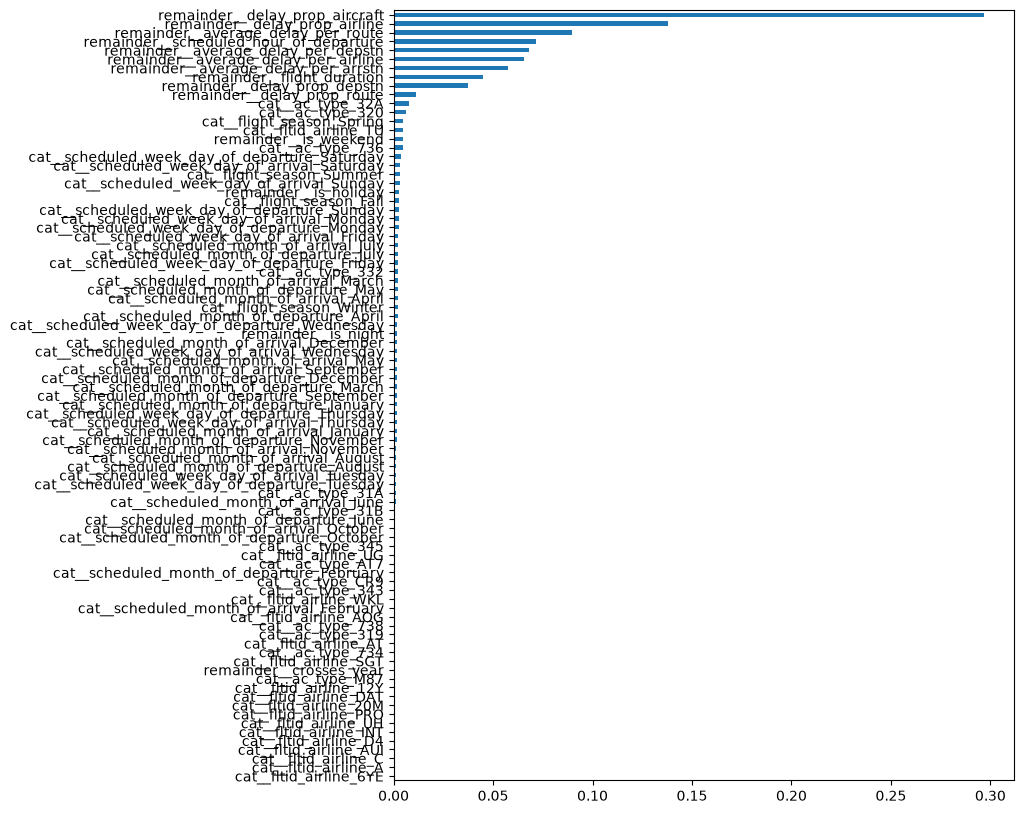

In [40]:
importances = best_rf.named_steps['model'].feature_importances_ 
feature_names = best_rf.named_steps['preprocess'].get_feature_names_out()
pd.Series(importances, index=feature_names).sort_values(ascending=True).plot(kind='barh', figsize=(8,10))

## References & Further Reading

- [**Flight Delay Prediction Challenge (Zindi)**](https://zindi.africa/competitions/flight-delay-prediction-challenge): the competition this notebook targets.
- `Flight_Delay_Baseline_and_Strategy_Report.pdf`: the fuller strategy report this notebook implements (data caveats, feature ideas, model comparison, validation pitfalls).
- [**root_mean_squared_error (scikit-learn)**](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.root_mean_squared_error.html): the evaluation metric used here and by the leaderboard.
- [**Ridge (scikit-learn)**](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html): the model behind Baseline 2.
- [**Common pitfalls and recommended practices (scikit-learn)**](https://scikit-learn.org/stable/common_pitfalls.html): general guidance on data leakage, directly relevant to the historical-average features planned for the next iteration.